# STAT201 · 1-hafta · Kompyuter laboratoriyasi (Python)

### Maʼlumot, tadqiqot dizayni, tavsifiy statistika va vizualizatsiya

**Toshkent Xalqaro Universiteti · Iqtisodiyot fakulteti · 2025/2026**

---

**Maqsad.** Maʼruzada qoʻlda hisoblangan tavsifiy koʻrsatkichlarni kod bilan
takrorlash, oʻzgaruvchi turlarini toʻgʻri aniqlash, taqsimotni vizual
tekshirish va grafikning chalgʻituvchi shaklini tanib olish.

**Ish zanjiri.** Har bir topshiriqda quyidagi ketma-ketlikni yozma ravishda
bajarasiz:

> **statistik tushuncha → maʼlumot → kod → natija → talqin → qaror**

Faqat kod yozib, natijani izohsiz qoldirish — topshiriq bajarilmagan
hisoblanadi. Baholashning yarmi aynan *talqin* va *qaror* bosqichlariga
beriladi.

**Bu daftar `W01-lab-R.Rmd` bilan aynan bir xil sonlarni beradi.** Oxirgi
boʻlimdagi «nazorat barmoq izi» buni tasdiqlaydi.

| Bosqich | Mazmun | Daqiqa |
|---|---|---|
| 0 | Muhitni sozlash | 5 |
| 1 | Maʼlumotni yuklash, tuzilma, oʻzgaruvchi turlari | 15 |
| 2 | Markaz va tarqoqlik; qoʻlda hisobni takrorlash | 20 |
| 3 | Guruhlangan xulosa jadvali (5 mamlakat) | 15 |
| 4 | Gistogramma va modallik | 15 |
| 5 | Quti diagrammalari va 1,5×IQR qoidasi | 20 |
| 6 | Vaqt qatori va chalgʻituvchi grafik | 20 |
| 7 | Ochiq topshiriq: boshqa ekin | 10 |

## 0-bosqich. Muhitni sozlash

In [1]:
# --- Kerakli kutubxonalar --------------------------------------------
# pandas     — jadval koʻrinishidagi maʼlumot (DataFrame)
# numpy      — sonli massivlar va statistik funksiyalar
# matplotlib — grafiklar
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__)

# Jadvallarni oʻqishga qulay qilib koʻrsatamiz.
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# Grafiklar daftar ichida chiqsin
%matplotlib inline

pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.9


In [2]:
# --- Grafiklarda oʻzbekcha «ʻ» belgisi (U+02BB) ----------------------
# matplotlib matnni tanlangan shrift bilan chizadi. Agar shriftda U+02BB
# («ʻ», tutuq belgisi) glifi boʻlmasa, uning oʻrnida QUTICHA (□) chiqadi
# va «Glyph 699 (MODIFIER LETTER TURNED COMMA) missing from font(s) ...»
# ogohlantirishi beriladi. Oʻrnatilgan shriftlarning koʻpchiligida bu
# belgi YOʻQ, shuning uchun shriftni TASODIFGA qoldirmang.
import warnings
from matplotlib import font_manager as fm


def check_font(nomzodlar=("DejaVu Sans", "Noto Sans", "Liberation Sans",
                          "FreeSans", "Charis SIL")):
    """Oʻzbekcha belgilarni chiza oladigan birinchi shriftni tanlaydi.

    Har bir nomzodni haqiqiy chizish orqali sinaydi: matn tarkibida
    «ʻ» (U+02BB) va «ʼ» (U+02BC) bor. Ogohlantirish chiqmasa — shrift mos.
    """
    sinov_matni = "Oʻzbekiston gʻalla maʼlumot ʻ ʼ"
    mavjud = {f.name for f in fm.fontManager.ttflist}
    for nom in nomzodlar:
        if nom not in mavjud:
            continue
        with warnings.catch_warnings(record=True) as ogoh:
            warnings.simplefilter("always")
            fig, ax = plt.subplots(figsize=(2, 0.6))
            plt.rcParams["font.family"] = nom
            ax.set_title(sinov_matni)
            fig.canvas.draw()          # chizishni majburlaydi
            plt.close(fig)
        yetishmagan = [w for w in ogoh if "missing from font" in str(w.message)]
        if not yetishmagan:
            return nom
    raise RuntimeError(
        "Oʻzbek harflarini qoʻllaydigan shrift topilmadi. "
        "DejaVu Sans yoki Noto Sans oʻrnating."
    )


SHRIFT = check_font()
plt.rcParams["font.family"] = SHRIFT
plt.rcParams["axes.unicode_minus"] = False   # minus belgisi ham toʻgʻri chiqsin
print("Tanlangan shrift:", SHRIFT)

# Nazorat: yetishmayotgan glif bormi?
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    fig, ax = plt.subplots(figsize=(4, 0.8))
    ax.set_title("Oʻzbekiston · bugʻdoy · maʼlumot · Qirgʻiziston")
    ax.axis("off")
    fig.canvas.draw()
    plt.close(fig)
print("Yetishmayotgan glif ogohlantirishlari:",
      sum("missing from font" in str(x.message) for x in w))

Tanlangan shrift: DejaVu Sans


Yetishmayotgan glif ogohlantirishlari: 0


In [3]:
# --- Umumiy grafik uslubi --------------------------------------------
# Okabe-Ito palitrasi: rang koʻrmaslikka moslashgan.
# Kursda maʼlumot ranglari faqat shu roʻyxatdan olinadi.
RANG_PALITRA = {
    "Oʻzbekiston":  "#0072B2",   # oiBlue
    "Qozogʻiston":  "#E69F00",   # oiOrange
    "Qirgʻiziston": "#009E73",   # oiGreen
    "Tojikiston":   "#CC79A7",   # oiPink
    "Turkmaniston": "#D55E00",   # oiVermillion
}

plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E8EC",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
})


def set_titles(ax, sarlavha, izoh=None):
    """Sarlavha va uning ostidagi izohni bir-birining ustiga tushmaydigan
    qilib joylashtiradi. pad — sarlavhani oʻqdan uzoqlashtiradi, shunda
    izoh matni ular orasiga sigʻadi."""
    ax.set_title(sarlavha, loc="left", pad=22 if izoh else 8)
    if izoh:
        ax.text(0.0, 1.015, izoh, transform=ax.transAxes,
                color="#5A6470", fontsize=9, va="bottom")

---
## 1-topshiriq. Maʼlumotni yuklash va tuzilmani tekshirish

**Qiyinlik: 1 (Asosiy) · Blum: Eslab qolish–Tushunish · 10 ball**

### Statistik tushuncha

Har qanday tahlil **kuzatuv birligi** *(observational unit)* nima ekanini
aniqlashdan boshlanadi. Bu yerda kuzatuv birligi — bitta *mamlakat–yil*
juftligi. Har bir ustun bitta **oʻzgaruvchi** *(variable)*, har bir qator
bitta **kuzatuv** *(observation)*.

Oʻzgaruvchilar tasnifi:

* **Sonli** *(numerical)*: **uzluksiz** *(continuous)* yoki **diskret**
  *(discrete)*;
* **Kategorik** *(categorical)*: **nominal** yoki **tartibli** *(ordinal)*.

### Maʼlumot

`data/markaziy-osiyo-hosildorlik.csv` — Our World in Data / FAOSTAT.
Hosildorlik **tonna/gektar** oʻlchovida, 1992–2018, 5 mamlakat.

In [4]:
# pd.read_csv() — vergul ajratgichli faylni DataFrame ga oʻqiydi.
# encoding="utf-8" — MAJBURIY: fayl ichida oʻzbekcha tutuq belgisi «ʻ»
# (U+02BB) bor. Kodlash notoʻgʻri boʻlsa «Oʻzbekiston» soʻzi
# «OÊ»zbekiston» koʻrinishida buziladi va filtrlash hech nima topmaydi.
hosildorlik = pd.read_csv(
    "data/markaziy-osiyo-hosildorlik.csv",
    encoding="utf-8",
)

# .shape — (qatorlar soni, ustunlar soni)
print(hosildorlik.shape)

(135, 7)


In [5]:
# .info() — R dagi str() ning ekvivalenti: ustun nomlari, turlari,
# boʻsh boʻlmagan qiymatlar soni va xotira hajmi.
hosildorlik.info()

<class 'pandas.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mamlakat     135 non-null    str    
 1   yil          135 non-null    int64  
 2   bugdoy       135 non-null    float64
 3   sholi        135 non-null    float64
 4   makkajoxori  135 non-null    float64
 5   kartoshka    135 non-null    float64
 6   arpa         135 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 7.5 KB


In [6]:
# .head(n) — dastlabki n qator. Maʼlumot toʻgʻri oʻqilganini koʻz bilan
# tekshirish uchun. «Oʻzbekiston» soʻzi buzilmaganini koʻring.
hosildorlik.head(5)

,mamlakat,yil,bugdoy,sholi,makkajoxori,kartoshka,arpa
0,Oʻzbekiston,1992,1.6620,3.2030,3.7230,8.5120,1.4100
1,Oʻzbekiston,1993,1.3580,3.2190,3.8410,10.6160,1.1570
2,Oʻzbekiston,1994,1.5150,3.1620,3.3980,10.7000,1.1080
3,Oʻzbekiston,1995,2.1420,1.9750,3.5070,9.5840,1.3910
4,Oʻzbekiston,1996,2.0640,1.9250,3.4390,11.5940,1.3530


In [7]:
# .dtypes — har bir ustunning saqlanish turi
print(hosildorlik.dtypes, "\n")

# .unique() — takrorlanmaydigan qiymatlar (kategorik oʻzgaruvchi darajalari)
print(hosildorlik["mamlakat"].unique(), "\n")

# yil ustunining chegaralari
print("yil:", hosildorlik["yil"].min(), "-", hosildorlik["yil"].max())

mamlakat           str
yil              int64
bugdoy         float64
sholi          float64
makkajoxori    float64
kartoshka      float64
arpa           float64
dtype: object 

<StringArray>
['Oʻzbekiston', 'Qirgʻiziston', 'Qozogʻiston', 'Tojikiston', 'Turkmaniston']
Length: 5, dtype: str 

yil: 1992 - 2018


In [8]:
# --- Yetishmayotgan qiymatlarni TEKSHIRISH (taxmin qilmang!) ---------
# .isna() — har bir katak uchun True/False
# .sum()  — ustunlar boʻyicha yigʻindi (True = 1)
print(hosildorlik.isna().sum(), "\n")
print("Jami yetishmayotgan katak:", int(hosildorlik.isna().sum().sum()), "\n")

# .value_counts() — chastota jadvali. Har bir mamlakatda necha yil bor?
print(hosildorlik["mamlakat"].value_counts())

mamlakat       0
yil            0
bugdoy         0
sholi          0
makkajoxori    0
kartoshka      0
arpa           0
dtype: int64 

Jami yetishmayotgan katak: 0 

mamlakat
Oʻzbekiston     27
Qirgʻiziston    27
Qozogʻiston     27
Tojikiston      27
Turkmaniston    27
Name: count, dtype: int64


### Natija (kutilayotgan)

```
shape                 : (135, 7)
mamlakat              : object  (kategorik, nominal)
yil                   : int64   (diskret, tartibli maʼnoga ega)
bugdoy ... arpa       : float64 (uzluksiz)
isna().sum().sum()    : 0
value_counts()        : har bir mamlakatda 27 ta
yil                   : 1992 - 2018
```

### Talqin — daftaringizga yozing

**T1.1** Jadvaldagi har bir ustunni tasniflang:

| Ustun | Sonli / Kategorik | Uzluksiz / Diskret / Nominal / Tartibli | Asos |
|---|---|---|---|
| `mamlakat` | | | |
| `yil` | | | |
| `bugdoy` | | | |
| `sholi` | | | |
| `makkajoxori` | | | |
| `kartoshka` | | | |
| `arpa` | | | |

**T1.2** `yil` ustuni `int64` turida saqlanadi. Bu uni **sonli
oʻzgaruvchi** qiladimi? `hosildorlik["yil"].mean()` qiymati statistik
maʼnoga egami? Javobingizni asoslang.

**T1.3** Yetishmayotgan qiymat `NaN` sifatida emas, balki `0`, `-999` yoki
boʻsh satr sifatida yozilgan boʻlishi mumkin. Quyidagi kod bilan tekshiring
va natijani izohlang.

In [9]:
# Nol yoki manfiy qiymatlar bormi? Hosildorlik nolga teng boʻlishi jismonan
# mumkin, lekin bu koʻpincha «maʼlumot yoʻq» ning yashiringan koʻrinishi.
ekin_ustunlari = ["bugdoy", "sholi", "makkajoxori", "kartoshka", "arpa"]
print((hosildorlik[ekin_ustunlari] <= 0).sum(), "\n")

# Eng kichik qiymatlar — mantiqan ishonarlimi?
print(hosildorlik[ekin_ustunlari].min())

bugdoy         0
sholi          0
makkajoxori    0
kartoshka      0
arpa           0
dtype: int64 

bugdoy        0.5200
sholi         0.3900
makkajoxori   0.2940
kartoshka     2.3080
arpa          0.1950
dtype: float64


### Qaror

Maʼlumot tozami? Tahlilga oʻtish mumkinmi? Agar yoʻq boʻlsa, avval nima
qilish kerak? Bir jumlada yozing.

---
## 2-topshiriq. Markaz va tarqoqlik: qoʻlda hisobni kod bilan takrorlash

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball**

### Statistik tushuncha

**Oʻrtacha arifmetik** *(mean)* va **median** *(median)* — markaz
koʻrsatkichlari; **kenglik** *(range)*, **kvartillararo kenglik (IQR)**
*(interquartile range)*, **dispersiya** *(variance)* va **standart ogʻish**
*(standard deviation)* — tarqoqlik koʻrsatkichlari.

$$\bar{x}=\frac{1}{n}\sum_{i=1}^{n} x_i, \qquad
s^{2}=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^{2}, \qquad
s=\sqrt{s^{2}}, \qquad
\mathrm{CV}=\frac{s}{\bar{x}}\cdot 100\%$$

Maxrajdagi $n-1$ — **erkinlik darajasi** *(degrees of freedom)*: $\bar{x}$
maʼlumotning oʻzidan hisoblangani uchun ogʻishlarning bittasi erkin emas.

### Maʼlumot

Oʻzbekiston, bugʻdoy, **2010–2018** ($n=9$) — maʼruzada qoʻlda hisoblangan
aynan shu toʻplam.

In [10]:
# Boolean maskalash — pandas da qatorlarni shart boʻyicha tanlash usuli.
# «&» — mantiqiy VA; har bir shart ALOHIDA qavs ichida boʻlishi shart,
# aks holda Python amallar tartibi tufayli xato beradi.
niqob = ((hosildorlik["mamlakat"] == "Oʻzbekiston") &
         (hosildorlik["yil"] >= 2010) &
         (hosildorlik["yil"] <= 2018))

uzb_bugdoy_2010 = hosildorlik.loc[niqob].sort_values("yil").reset_index(drop=True)

# .to_numpy() — ustunni oddiy numpy massiviga aylantiradi.
x = uzb_bugdoy_2010["bugdoy"].to_numpy()
print(x)
print("n =", len(x))

[4.6   4.556 4.71  4.739 4.782 4.818 4.802 4.316 4.126]
n = 9


In [11]:
# --- Markaz koʻrsatkichlari ------------------------------------------
n_kuzatuv = len(x)
yigindi   = x.sum()          # Sigma x
ortacha   = x.mean()         # x-chiziqcha
median_q  = np.median(x)     # median: tartiblangan qatorning oʻrtasi

print(f"n       = {n_kuzatuv}")
print(f"yigindi = {yigindi:.4f}")
print(f"ortacha = {ortacha:.4f}")
print(f"median  = {median_q:.4f}")

n       = 9
yigindi = 41.4490
ortacha = 4.6054
median  = 4.7100


In [12]:
# --- Tarqoqlik koʻrsatkichlari ---------------------------------------
# np.quantile(..., method="linear") — numpy ning standart usuli.
# U R dagi quantile(type = 7) bilan AYNAN bir xil, shuning uchun ikkala
# tilda natija bir xil chiqadi.
Q1 = np.quantile(x, 0.25, method="linear")
Q3 = np.quantile(x, 0.75, method="linear")
IQR_qiymat = Q3 - Q1
kenglik = x.max() - x.min()

# MUHIM: ddof=1 — TANLANMA formulasi (maxraj n-1).
# numpy ning standart qiymati ddof=0 (bosh toʻplam) — R dan FARQ QILADI!
dispersiya = x.var(ddof=1)
std_ogish  = x.std(ddof=1)
CV = 100 * std_ogish / ortacha

for nom, qiy in [("min", x.min()), ("Q1", Q1), ("median", median_q),
                 ("Q3", Q3), ("max", x.max()), ("IQR", IQR_qiymat),
                 ("kenglik", kenglik), ("dispersiya", dispersiya),
                 ("std_ogish", std_ogish), ("CV", CV)]:
    print(f"{nom:<12s} {qiy:10.4f}")

min              4.1260
Q1               4.5560
median           4.7100
Q3               4.7820
max              4.8180
IQR              0.2260
kenglik          0.6920
dispersiya       0.0575
std_ogish        0.2398
CV               5.2060


In [13]:
# --- Ogʻishlar jadvali: maʼruzadagi slaydni takrorlaymiz --------------
ogishlar = pd.DataFrame({
    "yil":        uzb_bugdoy_2010["yil"].to_numpy(),
    "x":          x,
    "ogish":      np.round(x - ortacha, 3),       # (x_i - x-chiziqcha)
    "ogish_kvad": np.round((x - ortacha) ** 2, 4),
})
print(ogishlar.to_string(index=False))

# Ogʻishlar yigʻindisi doim nolga teng — algebraik ayniyat.
# round(..., 12) — suzuvchi nuqtali sanoqdagi 1e-16 tartibidagi «chang»ni
# tozalaydi.
print("\nSigma(x - x-chiziqcha) =", round(float((x - ortacha).sum()), 12))

kvadratlar_yigindisi = float(((x - ortacha) ** 2).sum())
print("SS        =", round(kvadratlar_yigindisi, 6))
print("SS/(n-1)  =", round(kvadratlar_yigindisi / (n_kuzatuv - 1), 6))
print("var(ddof=1)=", round(float(x.var(ddof=1)), 6))   # bir xil boʻlishi shart

 yil      x   ogish  ogish_kvad
2010 4.6000 -0.0050      0.0000
2011 4.5560 -0.0490      0.0024
2012 4.7100  0.1050      0.0109
2013 4.7390  0.1340      0.0178
2014 4.7820  0.1770      0.0312
2015 4.8180  0.2130      0.0452
2016 4.8020  0.1970      0.0386
2017 4.3160 -0.2890      0.0838
2018 4.1260 -0.4790      0.2299

Sigma(x - x-chiziqcha) = 0.0
SS        = 0.459874
SS/(n-1)  = 0.057484
var(ddof=1)= 0.057484


In [14]:
# --- KENG TARQALGAN XATO: ddof ni unutish ----------------------------
# numpy: std() standart holatda ddof=0 — BOSH TOʻPLAM ogʻishi.
# pandas: .std() standart holatda ddof=1 — TANLANMA ogʻishi.
# Ikkisi turlicha! Qaysi biri kerakligini har safar ONGLI ravishda tanlang.
print(f"numpy  std(ddof=0) = {x.std(ddof=0):.6f}   <- bosh toʻplam (sigma)")
print(f"numpy  std(ddof=1) = {x.std(ddof=1):.6f}   <- tanlanma (s), R dagi sd()")
print(f"pandas .std()      = {uzb_bugdoy_2010['bugdoy'].std():.6f}  <- ddof=1")

numpy  std(ddof=0) = 0.226047   <- bosh toʻplam (sigma)
numpy  std(ddof=1) = 0.239759   <- tanlanma (s), R dagi sd()
pandas .std()      = 0.239759  <- ddof=1


### Natija (kutilayotgan)

```
n = 9        Sigma x = 41.4490     x-chiziqcha = 4.6054      median = 4.7100
Q1 = 4.5560  Q3 = 4.7820           IQR = 0.2260
min = 4.1260 max = 4.8180          kenglik = 0.6920
Sigma(x - x-chiziqcha)   = 0.0
SS = 0.459874
s^2 = 0.057484   s = 0.239759   CV = 5.2060 %
numpy std(ddof=0) = 0.226047   (bosh toʻplam sigma)
numpy std(ddof=1) = 0.239759   (tanlanma s)
```

Maʼruzadagi qoʻlda hisob: $\bar{x}=4{,}605$, $s=0{,}240$.
Kod: `4.6054`, `0.2398`. **Mos keladi.**

### Talqin

**T2.1** $\bar{x} = 4{,}605$, median $= 4{,}710$. $\bar{x} <$ median.
Taqsimot qaysi tomonga **qiyshiq** *(skewed)*? Qaysi kuzatuv buni keltirib
chiqaradi?

**T2.2** CV $= 5{,}2\%$. Bu koʻrsatkich nima uchun $s$ dan koʻra qulayroq?
Bugʻdoy ($s = 0{,}240$ t/ga) va kartoshka ($s \approx 8{,}42$ t/ga)
tarqoqligini bevosita solishtirish mumkinmi?

**T2.3 (barqarorlik tajribasi).** Quyidagi kodni bajaring va natijani
izohlang.

In [15]:
# Eng katta qiymatni (4.818) sunʼiy ravishda 12.0 ga almashtiramiz.
# Bu — «simulyatsiya qilingan maʼlumot», haqiqiy hosildorlik EMAS.
x_buzilgan = x.copy()                 # .copy() — asl massivni saqlab qolish
x_buzilgan[x_buzilgan.argmax()] = 12.0   # .argmax() — maksimum indeksi

print(f"ortacha_asl        = {x.mean():.4f}")
print(f"ortacha_buzilgan   = {x_buzilgan.mean():.4f}")
print(f"farq (ortacha)     = {x_buzilgan.mean() - x.mean():+.4f}")
print(f"median_asl         = {np.median(x):.4f}")
print(f"median_buzilgan    = {np.median(x_buzilgan):.4f}")
print(f"farq (median)      = {np.median(x_buzilgan) - np.median(x):+.4f}")

ortacha_asl        = 4.6054
ortacha_buzilgan   = 5.4034
farq (ortacha)     = +0.7980
median_asl         = 4.7100
median_buzilgan    = 4.7100
farq (median)      = +0.0000


Qaysi koʻrsatkich **barqaror** *(robust)*? Nima uchun?

### Qaror

Oʻzbekiston bugʻdoy hosildorligining 2010–2018 yillardagi tipik darajasini
hisobotda **bitta** son bilan bermoqchisiz. Qaysi koʻrsatkichni tanlaysiz —
oʻrtacha yoki median? Tanlovingizni yozing va bir jumlada asoslang.

---
## 3-topshiriq. Guruhlangan xulosa: beshta mamlakat

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash–Tahlil · 15 ball**

### Statistik tushuncha

**Beshlik xulosa** *(five-number summary)*: min, $Q_1$, median, $Q_3$, max.
Guruhlar boʻyicha hisoblanganda u guruhlararo farqni bir jadvalda koʻrsatadi.

### Maʼlumot

Bugʻdoy hosildorligi, **1992–2018**, har bir mamlakatda $n = 27$.

In [16]:
# .groupby() — keyingi amallarni har bir guruh ichida bajaradi.
# .agg()     — har bir guruhni bitta qatorga siqadi.
# Nomlangan agregatsiya (named aggregation) natija ustunlarini oʻqishga
# qulay qiladi.
xulosa_bugdoy = (
    hosildorlik
    .groupby("mamlakat")["bugdoy"]
    .agg(
        n="size",
        ortacha="mean",
        median="median",
        s="std",                                   # pandas: ddof=1
        min="min",
        max="max",
        Q1=lambda v: np.quantile(v, 0.25, method="linear"),
        Q3=lambda v: np.quantile(v, 0.75, method="linear"),
    )
    .reset_index()
)

# Yangi ustunlar
xulosa_bugdoy["IQR"] = xulosa_bugdoy["Q3"] - xulosa_bugdoy["Q1"]
xulosa_bugdoy["CV"] = 100 * xulosa_bugdoy["s"] / xulosa_bugdoy["ortacha"]

# Kamayish tartibida
xulosa_bugdoy = xulosa_bugdoy.sort_values("ortacha", ascending=False)

print(xulosa_bugdoy.round(3).to_string(index=False))

    mamlakat  n  ortacha  median      s    min    max     Q1     Q3    IQR      CV
 Oʻzbekiston 27   3.6050  4.1260 1.1790 1.3580 4.9010 2.6400 4.5780 1.9380 32.7200
Qirgʻiziston 27   2.2350  2.3170 0.2770 1.6750 2.7340 2.1010 2.4160 0.3150 12.4140
  Tojikiston 27   1.9910  1.9870 0.8530 0.8410 3.1470 1.1660 2.9710 1.8040 42.8290
Turkmaniston 27   1.9060  1.6000 0.8080 0.7760 3.5240 1.2350 2.5120 1.2770 42.3910
 Qozogʻiston 27   1.0270  1.0760 0.2600 0.5200 1.6610 0.8440 1.2030 0.3590 25.3150


In [17]:
# --- NaN va skipna haqida --------------------------------------------
# Bizda NaN yoʻq, shuning uchun bu hech nimani oʻzgartirmaydi.
# Lekin farqni bilish shart: pandas standart holatda NaN ni TASHLAB
# YUBORADI (skipna=True), numpy esa BUTUN natijani NaN qiladi.
sinov_pd = pd.Series([1.0, 2.0, np.nan, 4.0])
sinov_np = np.array([1.0, 2.0, np.nan, 4.0])
print("pandas .mean()          =", sinov_pd.mean())            # 2.3333
print("pandas .mean(skipna=0)  =", sinov_pd.mean(skipna=False))  # nan
print("numpy  .mean()          =", sinov_np.mean())            # nan
print("numpy  np.nanmean()     =", np.nanmean(sinov_np))       # 2.3333
# pandas ning «jimgina tashlab yuborishi» XAVFLI: u muammoni yashiradi.
# Avval .isna().sum() bilan tekshiring, keyin qaror qiling.

pandas .mean()          = 2.3333333333333335
pandas .mean(skipna=0)  = nan
numpy  .mean()          = nan
numpy  np.nanmean()     = 2.3333333333333335


### Natija (kutilayotgan)

| mamlakat | n | ortacha | median | s | min | max | Q1 | Q3 | IQR | CV |
|---|---|---|---|---|---|---|---|---|---|---|
| Oʻzbekiston | 27 | 3.605 | 4.126 | 1.179 | 1.358 | 4.901 | 2.640 | 4.578 | 1.938 | 32.720 |
| Qirgʻiziston | 27 | 2.235 | 2.317 | 0.277 | 1.675 | 2.734 | 2.101 | 2.416 | 0.315 | 12.414 |
| Tojikiston | 27 | 1.991 | 1.987 | 0.853 | 0.841 | 3.147 | 1.1665 | 2.971 | 1.8045 | 42.829 |
| Turkmaniston | 27 | 1.906 | 1.600 | 0.808 | 0.776 | 3.524 | 1.235 | 2.512 | 1.277 | 42.391 |
| Qozogʻiston | 27 | 1.027 | 1.076 | 0.260 | 0.520 | 1.661 | 0.844 | 1.203 | 0.359 | 25.315 |

> **Yaxlitlash haqida ogohlantirish.** Tojikiston uchun $Q_1 = 1{,}1665$ —
> aynan yarmi. Uch xonagacha yaxlitlaganda R `1.167`, Python esa `1.166`
> beradi. Bu **hisob xatosi emas**: ikkala dastur ham asl qiymati bir xil
> ($1{,}1665$), faqat «yarim» holatini turlicha yaxlitlaydi. Shuning uchun
> hisobotda yaxlitlangan sonlarni emas, hisoblash usulini bayon qiling.

### Talqin

**T3.1** Qozogʻistonda hosildorlik mintaqadagi eng past. Shu bilan birga
Qozogʻiston mintaqaning eng yirik bugʻdoy **eksportchisi**. Bu ziddiyat emas.
Nima uchun? (Maslahat: hosildorlik t/ga, eksport esa tonna.)

**T3.2** Oʻzbekiston uchun $\bar{x} = 3{,}605 <$ median $= 4{,}126$, lekin
2-topshiriqda 2010–2018 kichik toʻplamida $\bar{x} = 4{,}605$ edi. Nima
uchun butun davr oʻrtachasi bunchalik past?

**T3.3** Eng katta CV — Tojikiston (42,8 %), eng kichigi — Qirgʻiziston
(12,4 %). Bu nimani anglatadi? Qaysi mamlakat hosili yildan yilga
barqarorroq?

### Qaror

Mintaqaviy oziq-ovqat xavfsizligi hisoboti uchun mamlakatlarni **qaysi**
koʻrsatkich boʻyicha reytinglaysiz — oʻrtacha hosildorlik boʻyicha yoki CV
boʻyicha? Har bir tanlov qanday siyosiy xulosaga olib keladi?

---
## 4-topshiriq. Gistogramma: taqsimot shakli va modallik

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 15 ball**

### Statistik tushuncha

**Gistogramma** *(histogram)* — uzluksiz sonli oʻzgaruvchining taqsimotini
koʻrsatadi. Undan **modallik** (bir choʻqqili, ikki choʻqqili) va
**qiyshiqlik** *(skewness)* oʻqiladi. Ustunli diagrammadan farqi:
gistogrammada ustunlar tutashadi, chunki oʻq uzluksiz.

### Maʼlumot

Oʻzbekiston, bugʻdoy, 1992–2018 ($n = 27$).

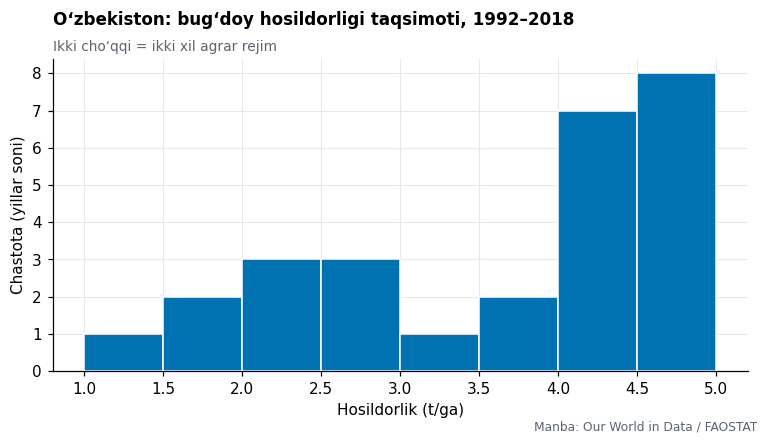

In [18]:
uzb_bugdoy = hosildorlik.loc[hosildorlik["mamlakat"] == "Oʻzbekiston"]

# Chegaralarni ANIQ belgilaymiz: shunda R va Python bir xil ustunlar beradi.
# np.arange(1.0, 5.01, 0.5) -> 1.0, 1.5, ..., 5.0
chegaralar = np.arange(1.0, 5.01, 0.5)

fig, ax = plt.subplots(figsize=(7, 4.0))
# ax.hist() — gistogramma. bins=chegaralar bilan oraliqlar [a, b)
# koʻrinishida boʻladi (oxirgisi [a, b] — yopiq).
ax.hist(uzb_bugdoy["bugdoy"], bins=chegaralar,
        color="#0072B2", edgecolor="white", linewidth=1.0)
ax.set_xticks(chegaralar)
ax.set_xlabel("Hosildorlik (t/ga)")
ax.set_ylabel("Chastota (yillar soni)")
set_titles(ax, "Oʻzbekiston: bugʻdoy hosildorligi taqsimoti, 1992–2018",
           "Ikki choʻqqi = ikki xil agrar rejim")
fig.text(0.99, 0.01, "Manba: Our World in Data / FAOSTAT",
         ha="right", fontsize=8, color="#5A6470")
fig.tight_layout()
plt.show()

In [19]:
# Grafikni sonlar bilan tasdiqlaymiz.
# np.histogram() — faqat chastotalarni qaytaradi, chizmaydi.
chastota, qirralar = np.histogram(uzb_bugdoy["bugdoy"], bins=chegaralar)
for i, c in enumerate(chastota):
    print(f"[{qirralar[i]:.1f}, {qirralar[i+1]:.1f})  {c}")

[1.0, 1.5)  1
[1.5, 2.0)  2
[2.0, 2.5)  3
[2.5, 3.0)  3
[3.0, 3.5)  1
[3.5, 4.0)  2
[4.0, 4.5)  7
[4.5, 5.0)  8


In [20]:
# Ikki choʻqqining sababini maʼlumotdan qidiramiz: yillar boʻyicha ajratamiz.
# np.where(shart, agar_rost, agar_yolgon) — vektorlashtirilgan shart.
davrlar = uzb_bugdoy.assign(
    davr=np.where(uzb_bugdoy["yil"] <= 2000, "1992-2000", "2001-2018")
)
print(
    davrlar.groupby("davr")["bugdoy"]
    .agg(n="size", ortacha="mean", min="min", max="max")
    .round(3).to_string()
)

            n  ortacha    min    max
davr                                
1992-2000   9   2.1040 1.3580 2.7170
2001-2018  18   4.3550 3.1510 4.9010


### Natija (kutilayotgan)

```
[1.0, 1.5)  1
[1.5, 2.0)  2
[2.0, 2.5)  3
[2.5, 3.0)  3
[3.0, 3.5)  1     <- pasayish («vodiy»)
[3.5, 4.0)  2
[4.0, 4.5)  7
[4.5, 5.0)  8

davr        n  ortacha  min    max
1992-2000   9  2.104    1.358  2.717
2001-2018  18  4.355    3.151  4.901
```

### Talqin

**T4.1** Taqsimot **ikki choʻqqili** *(bimodal)*. Ikkala choʻqqi qaysi
oraliqlarda? Ular orasidagi «vodiy» qayerda?

**T4.2** Ikki choʻqqi odatda **ikki xil populyatsiyaning aralashmasi**
belgisidir. Bu yerda ular nima? (Yuqoridagi `davr` jadvaliga qarang.)

**T4.3** Ikki choʻqqili taqsimot uchun **bitta** oʻrtacha ($3{,}605$)
hisoblash foydalimi? Bu son qaysi yilni tavsiflaydi?

**T4.4 (muhim)** Chegaralar sonini oʻzgartiring va shaklga taʼsirini
kuzating.

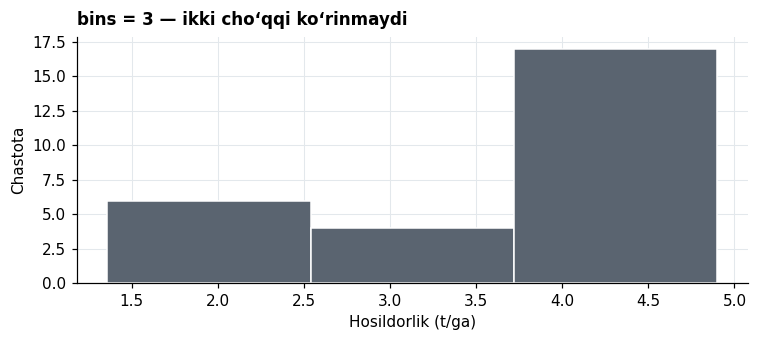

In [21]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(uzb_bugdoy["bugdoy"], bins=3, color="#5A6470", edgecolor="white")
set_titles(ax, "bins = 3 — ikki choʻqqi koʻrinmaydi")
ax.set_xlabel("Hosildorlik (t/ga)")
ax.set_ylabel("Chastota")
fig.tight_layout()
plt.show()

Gistogramma shakli tanlangan ustun kengligiga bogʻliq. Bu qanday xavf
tugʻdiradi?

### Qaror

Vazirlik hisobotiga bitta grafik joylashtirasiz. Gistogrammani qoldirasizmi
yoki vaqt qatoriga almashtirasizmi? Nima uchun?

---
## 5-topshiriq. Quti diagrammasi va 1,5×IQR qoidasi

**Qiyinlik: 4 (Analitik) · Blum: Tahlil–Baholash · 20 ball**

### Statistik tushuncha

**Quti diagrammasi** *(boxplot)* beshlik xulosani chizadi. **Chetlashgan
kuzatuv** *(outlier)* Tukey qoidasi boʻyicha aniqlanadi:

$$\text{quyi chegara}=Q_1-1{,}5\cdot \mathrm{IQR},\qquad
\text{yuqori chegara}=Q_3+1{,}5\cdot \mathrm{IQR}.$$

**Muhim:** chetlashgan kuzatuv — kuzatuvning *xossasi emas*, balki uning
**qaysi toʻplam bilan solishtirilayotganiga** bogʻliq nisbiy holat.

### Maʼlumot

Bugʻdoy: (a) 1992–2018, (b) faqat 2010–2018.

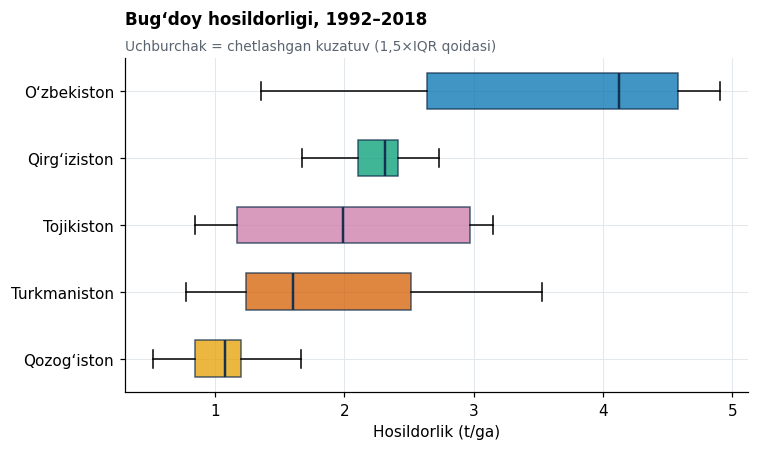

In [22]:
def draw_boxplots(df, ustun, sarlavha, izoh):
    """Mamlakatlar kesimida quti diagrammasi (median boʻyicha tartiblangan)."""
    # Medianga koʻra oʻsish tartibida — R dagi reorder() bilan bir xil
    tartib = df.groupby("mamlakat")[ustun].median().sort_values().index.tolist()
    maʼlumotlar = [df.loc[df["mamlakat"] == m, ustun].to_numpy() for m in tartib]

    fig, ax = plt.subplots(figsize=(7, 4.2))
    # whis=1.5 — aynan 1,5xIQR qoidasi (matplotlib ning standart qiymati).
    # matplotlib kvartillarni «linear» usulda hisoblaydi = R type 7.
    quti = ax.boxplot(
        maʼlumotlar, vert=False, widths=0.55, patch_artist=True,
        tick_labels=tartib, whis=1.5,
        medianprops=dict(color="#14314F", linewidth=1.6),
        flierprops=dict(marker="^", markersize=6,
                        markerfacecolor="#D55E00",
                        markeredgecolor="#D55E00"),
    )
    for yamoq, m in zip(quti["boxes"], tartib):
        yamoq.set_facecolor(RANG_PALITRA[m])
        yamoq.set_alpha(0.75)
        yamoq.set_edgecolor("#14314F")
    ax.set_xlabel("Hosildorlik (t/ga)")
    set_titles(ax, sarlavha, izoh)
    fig.tight_layout()
plt.show()


draw_boxplots(hosildorlik, "bugdoy",
              "Bugʻdoy hosildorligi, 1992–2018",
              "Uchburchak = chetlashgan kuzatuv (1,5×IQR qoidasi)")

In [23]:
# --- 1,5xIQR qoidasini kod bilan yozamiz ------------------------------
# Grafikka ishonmang — qoidani oʻzingiz hisoblang.
def find_outliers(qiymatlar):
    """Tukey ning 1,5xIQR qoidasi. Natija: chegaralar va indekslar."""
    qiymatlar = np.asarray(qiymatlar, dtype=float)
    Q1 = np.quantile(qiymatlar, 0.25, method="linear")
    Q3 = np.quantile(qiymatlar, 0.75, method="linear")
    iqr = Q3 - Q1
    quyi, yuqori = Q1 - 1.5 * iqr, Q3 + 1.5 * iqr
    # np.where(...)[0] — shartga mos elementlarning indekslari
    indeks = np.where((qiymatlar < quyi) | (qiymatlar > yuqori))[0]
    return {"Q1": Q1, "Q3": Q3, "IQR": iqr,
            "quyi": quyi, "yuqori": yuqori, "indeks": indeks}


def report_outliers(df, ustun):
    for mm in sorted(df["mamlakat"].unique()):
        qism = df.loc[df["mamlakat"] == mm].reset_index(drop=True)
        qiy = qism[ustun].to_numpy()
        yil = qism["yil"].to_numpy()
        r = find_outliers(qiy)
        topilgan = ("yoʻq" if len(r["indeks"]) == 0 else
                    ", ".join(f"{yil[i]} ({qiy[i]:.3f})" for i in r["indeks"]))
        print(f"{mm:<13s} IQR={r['IQR']:.4f}  "
              f"chegaralar=[{r['quyi']:.3f}; {r['yuqori']:.3f}]  "
              f"chetlashgan: {topilgan}")


print("(a) 1992-2018")
report_outliers(hosildorlik, "bugdoy")

(a) 1992-2018
Oʻzbekiston   IQR=1.9385  chegaralar=[-0.268; 7.486]  chetlashgan: yoʻq
Qirgʻiziston  IQR=0.3145  chegaralar=[1.630; 2.888]  chetlashgan: yoʻq
Qozogʻiston   IQR=0.3585  chegaralar=[0.306; 1.740]  chetlashgan: yoʻq
Tojikiston    IQR=1.8045  chegaralar=[-1.540; 5.678]  chetlashgan: yoʻq
Turkmaniston  IQR=1.2770  chegaralar=[-0.680; 4.427]  chetlashgan: yoʻq


In [24]:
# (b) Faqat 2010–2018 — aynan shu oynada 2018-yil koʻrinadi
qisqa = hosildorlik.loc[hosildorlik["yil"] >= 2010]
print("(b) 2010-2018")
report_outliers(qisqa, "bugdoy")

(b) 2010-2018
Oʻzbekiston   IQR=0.2260  chegaralar=[4.217; 5.121]  chetlashgan: 2018 (4.126)
Qirgʻiziston  IQR=0.2600  chegaralar=[1.755; 2.795]  chetlashgan: 2012 (1.675), 2014 (1.689)
Qozogʻiston   IQR=0.1520  chegaralar=[0.848; 1.456]  chetlashgan: 2010 (0.734), 2011 (1.661), 2012 (0.793)
Tojikiston    IQR=0.0800  chegaralar=[2.848; 3.168]  chetlashgan: 2011 (2.336), 2012 (2.676)
Turkmaniston  IQR=0.0870  chegaralar=[1.038; 1.386]  chetlashgan: 2010 (1.700)


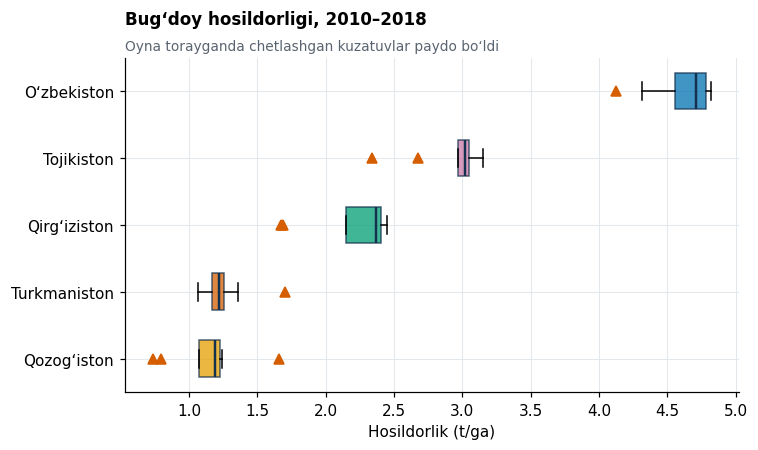

In [25]:
draw_boxplots(qisqa, "bugdoy",
              "Bugʻdoy hosildorligi, 2010–2018",
              "Oyna torayganda chetlashgan kuzatuvlar paydo boʻldi")

### Natija (kutilayotgan)

```
(a) 1992-2018:  BARCHA mamlakatda chetlashgan kuzatuv YOʻQ.
    Oʻzbekiston  IQR=1.9385  chegaralar=[-0.268; 7.486]
    Qirgʻiziston IQR=0.3145  chegaralar=[ 1.630; 2.888]
    Qozogʻiston  IQR=0.3585  chegaralar=[ 0.306; 1.740]
    Tojikiston   IQR=1.8045  chegaralar=[-1.540; 5.678]
    Turkmaniston IQR=1.2770  chegaralar=[-0.680; 4.427]

(b) 2010-2018:
    Oʻzbekiston  chegaralar=[4.217; 5.121]  -> 2018 (4.126)
    Qirgʻiziston chegaralar=[1.755; 2.795]  -> 2012 (1.675), 2014 (1.689)
    Qozogʻiston  chegaralar=[0.848; 1.456]  -> 2010 (0.734), 2011 (1.661),
                                               2012 (0.793)
    Tojikiston   chegaralar=[2.848; 3.168]  -> 2011 (2.336), 2012 (2.676)
    Turkmaniston chegaralar=[1.038; 1.386]  -> 2010 (1.700)
```

### Talqin

**T5.1** 1992–2018 davrida hech bir chetlashgan kuzatuv topilmadi, garchi
Oʻzbekistonda hosildorlik 1,358 dan 4,901 gacha, yaʼni 3,6 barobar
oʻzgargan boʻlsa ham. Nima uchun? (Maslahat: quyi chegara $-0{,}268$ —
manfiy hosildorlik mumkinmi?)

**T5.2** 2010–2018 oynasida 2018-yil (4,126 t/ga) chetlashgan deb
belgilandi. Xuddi shu qiymat butun davr uchun *median*ga teng (4,126).
Bir sonning ham median, ham chetlashgan kuzatuv boʻlishi qanday mumkin?

**T5.3** Chetlashgan kuzatuv topilganda uni **oʻchirish** kerakmi? 2018-yil
Oʻzbekistonda qurgʻoqchilik yili edi. Bu maʼlumot xatosimi yoki haqiqiy
hodisami? Qaysi holatda oʻchirish mumkin?

### Qaror

2018-yil kuzatuvi bilan nima qilasiz: qoldirasiz, oʻchirasiz yoki alohida
izohlaysiz? Qarorni yozing va uni himoya qiling.

---
## 6-topshiriq. Vaqt qatori va chalgʻituvchi grafik

**Qiyinlik: 5 (Ilgʻor) · Blum: Baholash · 20 ball**

### Statistik tushuncha

Vaqt qatorida $y$ oʻqining boshlanish nuqtasi — **dizayn qarori**, va u
oʻquvchining xulosasini oʻzgartiradi. **Oʻq kesilishi** *(truncated axis)* —
chalgʻituvchi grafikning eng keng tarqalgan shakli.

### Maʼlumot

Oʻzbekiston, bugʻdoy, 2010–2018.

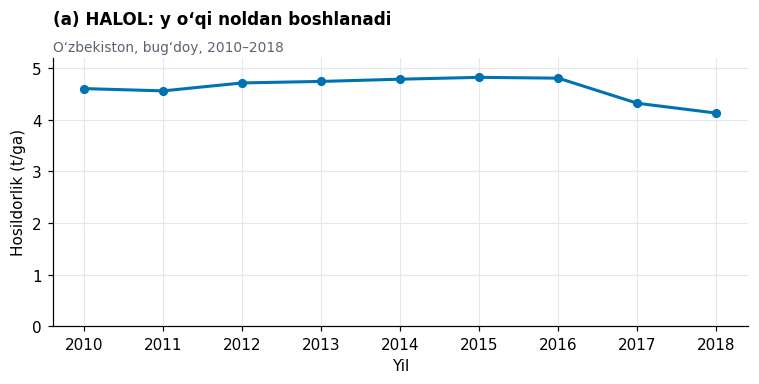

In [26]:
# --- (a) Halol grafik: y oʻqi noldan boshlanadi -----------------------
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(uzb_bugdoy_2010["yil"], uzb_bugdoy_2010["bugdoy"],
        color="#0072B2", linewidth=2, marker="o", markersize=5)
# set_ylim(bottom=0) — oʻqni majburan noldan boshlaydi
ax.set_ylim(0, 5.2)
ax.set_xticks(range(2010, 2019))
ax.set_xlabel("Yil")
ax.set_ylabel("Hosildorlik (t/ga)")
set_titles(ax, "(a) HALOL: y oʻqi noldan boshlanadi",
           "Oʻzbekiston, bugʻdoy, 2010–2018")
fig.tight_layout()
plt.show()

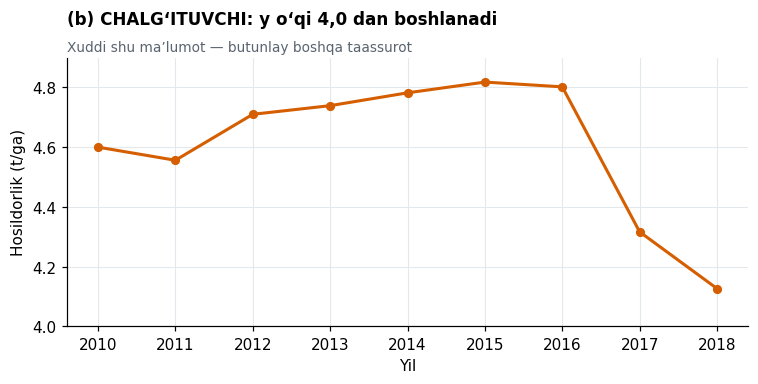

In [27]:
# --- (b) Chalgʻituvchi grafik: y oʻqi 4.0 dan boshlanadi --------------
# set_ylim() maʼlumotni KESMAYDI — faqat koʻrinishni oʻzgartiradi.
# Aynan shuning uchun u xavfli: hech qanday ogohlantirish chiqmaydi.
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(uzb_bugdoy_2010["yil"], uzb_bugdoy_2010["bugdoy"],
        color="#D55E00", linewidth=2, marker="o", markersize=5)
ax.set_ylim(4.0, 4.9)
ax.set_xticks(range(2010, 2019))
ax.set_xlabel("Yil")
ax.set_ylabel("Hosildorlik (t/ga)")
set_titles(ax, "(b) CHALGʻITUVCHI: y oʻqi 4,0 dan boshlanadi",
           "Xuddi shu maʼlumot — butunlay boshqa taassurot")
fig.tight_layout()
plt.show()

In [28]:
# --- Buzilishni son bilan oʻlchaymiz ----------------------------------
haqiqiy_pasayish = (4.126 - 4.818) / 4.818 * 100      # 2015 -> 2018, %

# Grafikdagi vertikal masofaning oʻq balandligiga nisbati:
kesilgan_ulush = (4.818 - 4.126) / (4.9 - 4.0) * 100  # kesilgan oʻqda
toliq_ulush    = (4.818 - 4.126) / (4.9 - 0.0) * 100  # noldan boshlanganda

print(f"haqiqiy_pasayish_foiz        = {haqiqiy_pasayish:8.2f}")
print(f"kesilgan_oqda_balandlik_foiz = {kesilgan_ulush:8.2f}")
print(f"toliq_oqda_balandlik_foiz    = {toliq_ulush:8.2f}")
print(f"bortirish_koeffitsiyenti     = {kesilgan_ulush / toliq_ulush:8.2f}")

haqiqiy_pasayish_foiz        =   -14.36
kesilgan_oqda_balandlik_foiz =    76.89
toliq_oqda_balandlik_foiz    =    14.12
bortirish_koeffitsiyenti     =     5.44


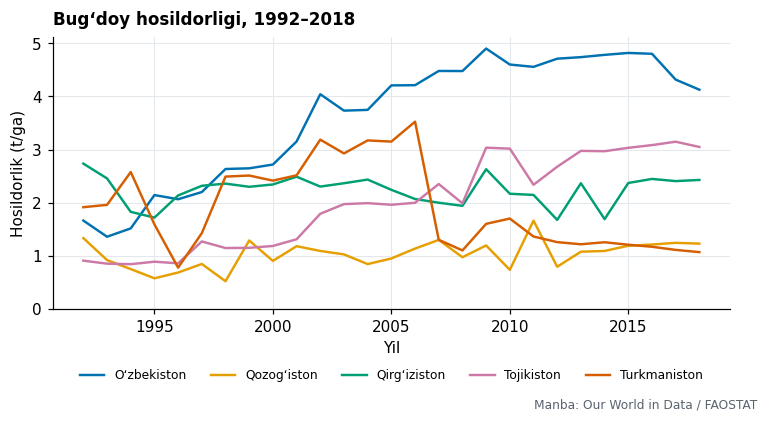

In [29]:
# --- Butun davr: kontekst nimani oʻzgartiradi? ------------------------
fig, ax = plt.subplots(figsize=(7, 3.8))
for m, rang in RANG_PALITRA.items():
    qism = hosildorlik.loc[hosildorlik["mamlakat"] == m].sort_values("yil")
    ax.plot(qism["yil"], qism["bugdoy"], label=m, color=rang, linewidth=1.6)
ax.set_ylim(0, None)
ax.set_xlabel("Yil")
ax.set_ylabel("Hosildorlik (t/ga)")
set_titles(ax, "Bugʻdoy hosildorligi, 1992–2018")
ax.legend(ncol=5, frameon=False, fontsize=8,
          loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.text(0.99, 0.01, "Manba: Our World in Data / FAOSTAT",
         ha="right", fontsize=8, color="#5A6470")
fig.tight_layout()
plt.show()

### Natija (kutilayotgan)

```
haqiqiy_pasayish_foiz         =   -14.36   (2015 -> 2018)
kesilgan_oqda_balandlik_foiz  =    76.89
toliq_oqda_balandlik_foiz     =    14.12
bortirish_koeffitsiyenti      =     5.44
```

### Talqin

**T6.1** Ikkala grafik **bir xil maʼlumot**dan chizilgan. Bir jumla bilan
tavsiflang: (a) grafikni koʻrgan odam nima deydi? (b) grafikni koʻrgan odam
nima deydi?

**T6.2** Boʻrtirish koeffitsiyenti 5,44 — yaʼni kesilgan oʻqda pasayish
qariyb 5,4 barobar kattaroq koʻrinadi. Shu bilan birga *hech qanday raqam
soxtalashtirilmagan*. Bu qanday qilib «yolgʻon aytmasdan aldash» mumkinligini
koʻrsatadi. Qanday holatlarda oʻqni kesish **maqbul**?

**T6.3** Uchinchi grafikda 1992–2018 butun davri koʻrsatilgan. 2010–2018
dagi pasayish shu kontekstda qanday koʻrinadi? Kontekst xulosani
oʻzgartiradimi?

### Qaror

Siz Qishloq xoʻjaligi vazirligining tahlilchisisiz. Matbuot anjumaniga
qaysi grafikni tanlaysiz va nima uchun? Endi siz mustaqil jurnalistsiz —
tanlovingiz oʻzgaradimi? Ikkala javobni yozing.

---
## 7-topshiriq. Ochiq topshiriq: boshqa ekinni tahlil qiling

**Qiyinlik: 6 (Tadqiqotga yoʻnaltirilgan) · Blum: Yaratish · 20 ball**

### Vazifa

`sholi`, `makkajoxori`, `kartoshka` yoki `arpa` ustunlaridan **bittasini**
tanlang va toʻliq tavsifiy tahlil oʻtkazing. Har bir qadamda **nima uchun**
aynan shu tanlovni qilganingizni yozing.

Talab qilinadi:

1. Ekin tanlovi va uning iqtisodiy ahamiyati (2–3 jumla).
2. Beshta mamlakat boʻyicha xulosa jadvali (3-topshiriq uslubida).
3. **Bitta** grafik — turini oʻzingiz tanlaysiz va tanlovni asoslaysiz.
4. Kamida bitta chetlashgan kuzatuvni topib, uni tekshiring: bu maʼlumot
   xatosimi yoki haqiqiy hodisami?
5. Bitta amaliy tavsiya (siyosat yoki biznes qarori).

In [30]:
# «ekin» oʻzgaruvchisini oʻzingiz oʻzgartiring: "sholi", "makkajoxori",
# "kartoshka" yoki "arpa".
ekin = "kartoshka"

xulosa_ekin = (
    hosildorlik
    .groupby("mamlakat")[ekin]
    .agg(n="size", ortacha="mean", median="median", s="std",
         min="min", max="max")
    .reset_index()
)
xulosa_ekin["CV"] = 100 * xulosa_ekin["s"] / xulosa_ekin["ortacha"]
xulosa_ekin = xulosa_ekin.sort_values("ortacha", ascending=False)

print(xulosa_ekin.round(3).to_string(index=False))

    mamlakat  n  ortacha  median      s     min     max      CV
 Oʻzbekiston 27  20.2380 18.5540 8.4160  8.5120 35.7020 41.5850
  Tojikiston 27  18.3560 19.4320 5.4770 10.0290 27.9000 29.8390
Turkmaniston 27  16.3360 17.7480 5.4150  2.3080 22.2520 33.1470
Qirgʻiziston 27  15.1630 15.8220 2.8210  9.0910 23.7870 18.6020
 Qozogʻiston 27  13.9540 14.3190 3.7840  7.6680 19.7940 27.1180


In [31]:
# Chetlashgan kuzatuvlarni qidirish (report_outliers 5-topshiriqda yozilgan)
report_outliers(hosildorlik, ekin)

Oʻzbekiston   IQR=13.0685  chegaralar=[-6.501; 45.773]  chetlashgan: yoʻq
Qirgʻiziston  IQR=2.2700  chegaralar=[10.725; 19.805]  chetlashgan: 1994 (9.091), 1995 (9.853), 2002 (23.787)
Qozogʻiston   IQR=6.0405  chegaralar=[1.554; 25.716]  chetlashgan: yoʻq
Tojikiston    IQR=10.8665  chegaralar=[-3.837; 39.629]  chetlashgan: yoʻq
Turkmaniston  IQR=5.9395  chegaralar=[4.931; 28.689]  chetlashgan: 1994 (2.308)


### Nazorat natijasi (kartoshka uchun — oʻqituvchi tekshiruvi)

```
Oʻzbekiston  ortacha=20.238  median=18.554  s=8.416  min=8.512  max=35.702  CV=41.59
Tojikiston   ortacha=18.356  median=19.432  s=5.477  min=10.029 max=27.900  CV=29.84
Turkmaniston ortacha=16.336  median=17.748  s=5.415  min=2.308  max=22.252  CV=33.15
Qirgʻiziston ortacha=15.163  median=15.822  s=2.821  min=9.091  max=23.787  CV=18.60
Qozogʻiston  ortacha=13.954  median=14.319  s=3.784  min=7.668  max=19.794  CV=27.12

Chetlashgan kuzatuvlar:
Qirgʻiziston  1994 (9.091), 1995 (9.853), 2002 (23.787)
Turkmaniston  1994 (2.308)
```

---
## Nazorat barmoq izi (R ↔ Python tengligini tekshirish)

Bu boʻlim laboratoriya natijalarining **ikkala tilda bir xil** ekanini
tasdiqlaydi. `W01-lab-R.Rmd` va bu daftar aynan shu jadvalni chiqarishi
shart — satrma-satr, belgi-belgi.

In [32]:
KODLAR = ["UZB", "KAZ", "KGZ", "TJK", "TKM"]
NOMLAR = ["Oʻzbekiston", "Qozogʻiston", "Qirgʻiziston",
          "Tojikiston", "Turkmaniston"]


def print_row(nom, qiymat):
    """Nomni chapga, sonni oʻngga tekislab chiqaradi (R bilan bir xil format)."""
    print(f"{nom:<34s} {float(qiymat):16.6f}")


def q(v, p):
    return float(np.quantile(np.asarray(v, dtype=float), p, method="linear"))


print("=== STAT201 W01 LAB · NUMERIC FINGERPRINT ===")
print("--- A. Uzbekistan wheat 2010-2018 (n=9) ---")
print_row("A01_n",                   len(x))
print_row("A02_sum",                 x.sum())
print_row("A03_mean",                x.mean())
print_row("A04_median",              np.median(x))
print_row("A05_Q1",                  q(x, .25))
print_row("A06_Q3",                  q(x, .75))
print_row("A07_IQR",                 q(x, .75) - q(x, .25))
print_row("A08_min",                 x.min())
print_row("A09_max",                 x.max())
print_row("A10_range",               x.max() - x.min())
print_row("A11_sum_deviations",      round(float((x - x.mean()).sum()), 10) + 0.0)
print_row("A12_sum_sq_deviations",   ((x - x.mean()) ** 2).sum())
print_row("A13_variance_s2",         x.var(ddof=1))
print_row("A14_sd_sample",           x.std(ddof=1))
print_row("A15_cv_percent",          100 * x.std(ddof=1) / x.mean())
print_row("A16_sd_population",       np.sqrt(((x - x.mean()) ** 2).sum() / len(x)))
print_row("A17_fence_low",           q(x, .25) - 1.5 * (q(x, .75) - q(x, .25)))
print_row("A18_fence_high",          q(x, .75) + 1.5 * (q(x, .75) - q(x, .25)))
print_row("A19_mean_contaminated",   x_buzilgan.mean())
print_row("A20_median_contaminated", np.median(x_buzilgan))

print("--- B. Wheat by country 1992-2018 (n=27 each) ---")
for kod, nom in zip(KODLAR, NOMLAR):
    v = hosildorlik.loc[hosildorlik["mamlakat"] == nom, "bugdoy"].to_numpy()
    print_row(f"B_{kod}_mean",   v.mean())
    print_row(f"B_{kod}_median", np.median(v))
    print_row(f"B_{kod}_sd",     v.std(ddof=1))
    print_row(f"B_{kod}_min",    v.min())
    print_row(f"B_{kod}_max",    v.max())
    print_row(f"B_{kod}_Q1",     q(v, .25))
    print_row(f"B_{kod}_Q3",     q(v, .75))
    print_row(f"B_{kod}_cv",     100 * v.std(ddof=1) / v.mean())

print("--- C. Uzbekistan wheat histogram, breaks 1.0(0.5)5.0 ---")
hist_chastota, _ = np.histogram(uzb_bugdoy["bugdoy"], bins=chegaralar)
for j, c in enumerate(hist_chastota, start=1):
    print_row(f"C_bin{j:02d}_[{chegaralar[j-1]:.1f},{chegaralar[j]:.1f})", c)

print("--- D. Outlier counts (1.5 x IQR) ---")


def count_outliers(df, ustun):
    return sum(len(find_outliers(df.loc[df["mamlakat"] == nom, ustun])["indeks"])
               for nom in NOMLAR)


print_row("D01_wheat_1992_2018_outliers",  count_outliers(hosildorlik, "bugdoy"))
print_row("D02_wheat_2010_2018_outliers",  count_outliers(qisqa, "bugdoy"))
print_row("D03_potato_1992_2018_outliers", count_outliers(hosildorlik, "kartoshka"))

print("--- E. Truncated-axis distortion ---")
print_row("E01_real_change_pct",      (4.126 - 4.818) / 4.818 * 100)
print_row("E02_height_truncated_pct", (4.818 - 4.126) / (4.9 - 4.0) * 100)
print_row("E03_height_full_pct",      (4.818 - 4.126) / (4.9 - 0.0) * 100)
print_row("E04_exaggeration_factor",
          ((4.818 - 4.126) / 0.9) / ((4.818 - 4.126) / 4.9))

print("--- F. Potato by country 1992-2018 ---")
for kod, nom in zip(KODLAR, NOMLAR):
    v = hosildorlik.loc[hosildorlik["mamlakat"] == nom, "kartoshka"].to_numpy()
    print_row(f"F_{kod}_mean", v.mean())
    print_row(f"F_{kod}_sd",   v.std(ddof=1))

print("--- G. Data integrity ---")
print_row("G01_rows",          hosildorlik.shape[0])
print_row("G02_cols",          hosildorlik.shape[1])
print_row("G03_missing_cells", hosildorlik.isna().sum().sum())
print_row("G04_year_min",      hosildorlik["yil"].min())
print_row("G05_year_max",      hosildorlik["yil"].max())
print_row("G06_countries",     hosildorlik["mamlakat"].nunique())
uz = hosildorlik.loc[hosildorlik["mamlakat"] == NOMLAR[0]]
a = float(uz.loc[uz["yil"] == 1992, "bugdoy"].iloc[0])
b = float(uz.loc[uz["yil"] == 2018, "bugdoy"].iloc[0])
print_row("G07_uzb_change_pct_1992_2018", 100 * (b - a) / a)
print("=== END FINGERPRINT ===")

=== STAT201 W01 LAB · NUMERIC FINGERPRINT ===
--- A. Uzbekistan wheat 2010-2018 (n=9) ---
A01_n                                      9.000000
A02_sum                                   41.449000
A03_mean                                   4.605444
A04_median                                 4.710000
A05_Q1                                     4.556000
A06_Q3                                     4.782000
A07_IQR                                    0.226000
A08_min                                    4.126000
A09_max                                    4.818000
A10_range                                  0.692000
A11_sum_deviations                         0.000000
A12_sum_sq_deviations                      0.459874
A13_variance_s2                            0.057484
A14_sd_sample                              0.239759
A15_cv_percent                             5.205986
A16_sd_population                          0.226047
A17_fence_low                              4.217000
A18_fence_high            

---
## Baholash mezonlari (jami 120 ball)

| Topshiriq | Kod ishlaydi | Toʻgʻri natija | Talqin | Qaror | Jami |
|---|---|---|---|---|---|
| 1 | 3 | 3 | 3 | 1 | **10** |
| 2 | 5 | 6 | 6 | 3 | **20** |
| 3 | 4 | 4 | 5 | 2 | **15** |
| 4 | 4 | 3 | 5 | 3 | **15** |
| 5 | 5 | 5 | 7 | 3 | **20** |
| 6 | 4 | 4 | 8 | 4 | **20** |
| 7 | 5 | 4 | 6 | 5 | **20** |
| | | | | | **120** |

Faqat kod va sonlar → maksimal 45 %. Talqin va qarorsiz ish toʻliq
baholanmaydi.

---

## Keng tarqalgan xatolar

1. **Kodlash (encoding).** `pd.read_csv()` ni `encoding` koʻrsatmasdan
   ishlatish. Windows da standart kodlash `cp1251`/`cp1252` boʻlishi
   mumkin va `Oʻzbekiston` `OÊ»zbekiston` boʻlib buziladi; keyin
   `df["mamlakat"] == "Oʻzbekiston"` **hech nima topmaydi** va tahlil
   boʻsh jadval ustida ishlaydi. **Yechim:**
   `pd.read_csv(..., encoding="utf-8")`. Tekshirish: `df.head()` da
   `Oʻzbekiston` toʻgʻri koʻrinishi kerak.
2. **`ddof` ni unutish.** `np.std(x)` standart holatda **ddof=0** —
   bosh toʻplam ogʻishi; R dagi `sd()` esa **ddof=1**. Tanlanma standart
   ogʻishi uchun har doim `x.std(ddof=1)` yozing. `pandas.Series.std()`
   esa standart holatda ddof=1 — ikkita kutubxona ikki xil!
3. **pandas NaN ni jimgina tashlab yuboradi.** `.mean()` standart holatda
   `skipna=True`. Bu muammoni yashiradi. Avval `.isna().sum()` bilan
   tekshiring. numpy esa `nan` qaytaradi — bu ochiqroq xatti-harakat.
4. **`object` va `category` farqi.** `read_csv()` matnni `object` qilib
   oʻqiydi. Tartibni boshqarish uchun
   `pd.Categorical(..., categories=[...], ordered=True)` kerak; aks holda
   grafiklarda kategoriyalar tasodifiy tartibda chiqadi.
5. **Kvantil usuli.** `np.quantile(..., method="linear")` — standart va
   R dagi `type = 7` bilan mos. `method="midpoint"` yoki `"nearest"` esa
   BOSHQA natija beradi va R bilan mos kelmaydi.
6. **`=` va `==`.** `df["mamlakat"] = "..."` butun ustunni qayta yozadi;
   solishtirish uchun `==` kerak. Bu xato ogohlantirishsiz maʼlumotni
   buzadi.
7. **Vergul va nuqta.** Kodda **nuqta** (`4.605`), oʻzbekcha matnda
   **vergul** (`4,605`).
8. **`isna().sum() == 0` ni «maʼlumot toza» deb tushunish.** Yashiringan
   yoʻqolishlar `0`, `-999`, `""` boʻlishi mumkin.
9. **Grafikda «ʻ» oʻrniga quticha (□) chiqishi.** matplotlib tanlangan
   shriftda U+02BB glifi boʻlmasa quticha chizadi va
   `Glyph 699 (MODIFIER LETTER TURNED COMMA) missing from font(s) ...`
   ogohlantirishini beradi. Sinovda: `DejaVu Sans` (matplotlib ning
   standart shrifti) — **0 ta** ogohlantirish; `Accanthis ADF Std` kabi
   shrift — **6 ta** ogohlantirish va buzilgan sarlavha. Tizimda
   oʻrnatilgan shriftlarning koʻpchiligida bu belgi **yoʻq**, shuning
   uchun shriftni tasodifga qoldirmang. **Yechim:** 0-bosqichdagi
   `check_font()` funksiyasi — u shriftni haqiqiy chizish orqali sinaydi
   va mos birinchisini tanlaydi:
   `plt.rcParams["font.family"] = "DejaVu Sans"`.
10. **Bir xil raqam, boshqa yaxlitlash.** «Yarim» qiymatlarda (masalan
   $1{,}1665$) R va Python turlicha yaxlitlaydi. Yaxlitlangan sonni emas,
   usulni hisobot qiling.

---

## Topshirish

* Fayl: `W01-lab-<familiya>.ipynb` (bajarilgan natijalar bilan saqlangan).
* Kod ishlashi shart: `Kernel → Restart & Run All` xatosiz oʻtishi kerak.
* Har bir topshiriq uchun talqin va qaror Markdown kataklarida yozilgan
  boʻlishi shart.
* Muddat: laboratoriyadan keyingi 48 soat, Moodle.
* Sunʼiy intellektdan foydalansangiz, qaysi qismda va qanday
  foydalanganingizni oxirida deklaratsiya qiling.

In [33]:
# Ishning takrorlanuvchanligi uchun muhit maʼlumotini ilova qiling.
import sys, platform
print("Python     :", sys.version.split()[0])
print("Platforma  :", platform.platform())
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("matplotlib :", matplotlib.__version__)
print("Shrift     :", plt.rcParams["font.family"])

Python     : 3.11.15
Platforma  : Linux-6.18.5-fc-v20-x86_64-with-glibc2.39
pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.9
Shrift     : ['DejaVu Sans']
